# Planisferio de Wenu — versión de dibujo explícito

Esta versión dibuja cada componente explícitamente en lugar de depender de `CelestialSphere.draw()`.
El disco de horizonte relleno se coloca obligatoriamente detrás de cada capa astronómica.


In [1]:
import inspect
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

import wenu
print(f"Wenu version: {wenu.__version__}")
from wenu.observer import Observer
from wenu.projection import StereographicProjection
from wenu.renderers import layers
from wenu.sky import CelestialSphere
from wenu.resources import catalog_path, constellation_lines_path, boundary_path


Wenu version: 0.1.dev17+gd0eff04a6.d20260723


In [2]:

MAGNITUDE_LIMIT=6.0
PROJECTION_RADIUS=2.0
FLIP_EAST_WEST=True
#SKY_COLOR="slateblue"
SKY_COLOR="white"
STAR_COLOR="black"
SELECTED_CONSTELLATIONS=None
RA_GRID_DEG=list(range(0,360,30))
DEC_GRID_DEG=[-60.0,-30.0,0.0,30.0,60.0]
ECL_LONG = list(range(0, 360, 30))
ECL_LAT =[-60.0, -30.0, 0.0, 30.0, 60.0]
GAL_LONG = list(range(0, 360, 30))
GAL_LAT =[-60.0, -30.0, 0.0, 30.0, 60.0]


In [3]:
observer = Observer(
    location="La Ligua",
    time="2026-08-15 21:00",
)


In [4]:
print("Hipparcos:",catalog_path("hipparcos"))
print("Western lines:",constellation_lines_path("western"))
print("IAU boundaries:",boundary_path("iau"))


Hipparcos: /Users/fselman/odrive/Dropbox/software/wenu/src/wenu/data/catalogs/hipparcos/hip_main.dat
Western lines: /Users/fselman/odrive/Dropbox/software/wenu/src/wenu/data/constellations/western/const_aug.fab
IAU boundaries: /Users/fselman/odrive/Dropbox/software/wenu/src/wenu/data/constellations/iau/bound_18.dat


In [5]:
projection=StereographicProjection(radius=PROJECTION_RADIUS,flip_ew=FLIP_EAST_WEST)
sky=CelestialSphere(observer=observer)
stars=sky.add_stars(catalog="hipparcos",magnitude_limit=MAGNITUDE_LIMIT)
constellations=sky.add_constellations(system="western",selected=SELECTED_CONSTELLATIONS)
boundaries=sky.add_constellation_boundaries(boundaries="iau",constellations=SELECTED_CONSTELLATIONS)
boundaries.sample()
points=sky.add_points()
points.add_equatorial_pole(pole="visible",marker="+",label="SCP",size=120,color="white",zorder=layers.POINTS)
points.add_ecliptic_pole(pole="south",marker="+",label="SEP",size=80,color="darkorange",zorder=layers.POINTS)
points.add_ecliptic_keypoints(marker="+",size=70,color="cyan",zorder=layers.POINTS)
points.add_galactic_center(marker="+",label="GC",size=80,color="lightblue",zorder=layers.POINTS)


In [6]:
for name,method in {
"stars.draw":stars.draw,
"constellations.draw_lines":constellations.draw_lines,
"constellations.draw_labels":constellations.draw_labels,
"boundaries.draw":boundaries.draw,
"points.draw":points.draw,
"sky.draw_equatorial_grid":sky.draw_equatorial_grid,
}.items():
    print(f"{name}{inspect.signature(method)}")


stars.draw(ax, projection, color='white', alt_min=-10.0, zorder=5, **scatter_kwargs)
constellations.draw_lines(ax, projection, **kwargs)
constellations.draw_labels(ax, *, selected=None, min_stars=3, radial_cut=None, fontsize=10, color='white', alpha=0.85, outward_offset=0.04, zorder=5)
boundaries.draw(ax, projection)
points.draw(ax, projection)
sky.draw_equatorial_grid(ax, projection, *, ra=None, dec=None, frame='fk5', equinox='of_date', samples=721, min_altitude=0.0, meridian_style=None, parallel_style=None, **style)


In [7]:
fig,ax=plt.subplots(figsize=(15,15))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)
sky_disk=Circle((0,0),PROJECTION_RADIUS,edgecolor="black",facecolor=SKY_COLOR,linewidth=1.5,zorder=-1000)
ax.add_patch(sky_disk)
ax.set_aspect("equal")
ax.set_xlim(-1.04*PROJECTION_RADIUS,1.04*PROJECTION_RADIUS)
ax.set_ylim(-1.04*PROJECTION_RADIUS,1.04*PROJECTION_RADIUS)
ax.axis("off")
plt.close(fig)

In [8]:
boundary_artists = boundaries.draw(
    ax=ax,
    projection=projection,
)
for artist in boundary_artists:
    artist.set_color("royalblue")
    artist.set_linewidth(0.5)
    artist.set_alpha(0.7)
    
print("Number of boundary segments:", len(boundary_artists))

Number of boundary segments: 74


In [9]:
sky.draw_ecliptic(
    ax=ax,
    projection=projection,
    color="darkorange",
    linewidth=1.0,
    linestyle="-",
    alpha=0.9,
    zorder=layers.CURVES,
)

In [10]:
sky.draw_galactic_plane(
    ax=ax,
    projection=projection,
    color="steelblue",
    linewidth=1.0,
    linestyle="--",
    alpha=0.9,
    zorder=layers.CURVES,
)

In [11]:
plot_eq_grid = True
plot_ec_grid = False
plot_gal_grid = False

if plot_eq_grid :
    eq_artists=sky.draw_equatorial_grid(ax=ax,projection=projection,ra=RA_GRID_DEG,dec=DEC_GRID_DEG,color="white",linewidth=0.4,alpha=0.35,zorder=layers.CURVES)
    for artist in eq_artists:
        artist.set_color("darkgrey")
        artist.set_linewidth(0.6)
        artist.set_linestyle((0, (1, 2)))
        artist.set_alpha(0.8)

if plot_ec_grid :
    ec_artists = sky.draw_ecliptic_grid(
        ax=ax,
        projection=projection,
        longitude=ECL_LONG,
        latitude=ECL_LAT,
    )
    for artist in ec_artists:
        artist.set_color("darkorange")
        artist.set_linewidth(0.8)
        artist.set_linestyle((0, (1, 2)))
        artist.set_alpha(0.8)

if plot_ec_grid :
    gal_artists = sky.draw_galactic_grid(
    ax=ax,
    projection=projection,
    longitude=GAL_LONG,
    latitude=GAL_LAT,
    )

    for artist in gal_artists:
        artist.set_color("steelblue")
        artist.set_linewidth(0.8)
        artist.set_linestyle((0, (1, 2)))
        artist.set_alpha(0.8)

In [12]:
params=inspect.signature(stars.draw).parameters
if "observer" in params or "obs" in params:
    star_artists=stars.draw(ax,observer,t,projection,color=STAR_COLOR,alt_min=0.0)
else:
    star_artists=stars.draw(ax=ax,projection=projection,color=STAR_COLOR)
print("Star artists:",star_artists)

Star artists: <matplotlib.collections.PathCollection object at 0x11bb5c350>


In [13]:
constellation_line_artists = constellations.draw_lines(
    ax=ax,
    projection=projection,
)
for artist in constellation_line_artists:
    artist.set_color("grey")
    artist.set_linewidth(0.7)
    
print(
    "Number of constellation-line segments:",
    len(constellation_line_artists),
)
print("Lines after constellation lines:", len(ax.lines))

Number of constellation-line segments: 400
Lines after constellation lines: 493


In [14]:
import inspect

print(inspect.signature(constellations.draw_labels))
print(inspect.getsource(constellations.draw_labels))

(ax, *, selected=None, min_stars=3, radial_cut=None, fontsize=10, color='white', alpha=0.85, outward_offset=0.04, zorder=5)
    def draw_labels(
        self,
        ax,
        *,
        selected=None,
        min_stars=3,
        radial_cut=None,
        fontsize=10,
        color="white",
        alpha=0.85,
        outward_offset=0.04,
        zorder=5,
    ):
        """
        Draw constellation labels.

        Serpens stars are divided between the two official boundary
        polygons, SER1 and SER2, and labelled SerCap and SerCau.
        """

        self._validate_stars()

        selected = self._resolve_selected(selected)
        stars = self.stars

        hip_to_constellation = self._build_hip_to_constellation(
            stars.hip_df
        )

        points = defaultdict(list)

        for hip_id in stars.hip_df.index:
            hip_id = int(hip_id)

            iau_constellation = hip_to_constellation.get(
                hip_id
            )

            if i

In [15]:
constellation_label_artists = constellations.draw_labels(
    ax=ax,
    selected=SELECTED_CONSTELLATIONS,
    min_stars=3,
    radial_cut=3.0,
    fontsize=10,
    color="white",
    alpha=0.85,
    outward_offset=0.04,
    zorder=layers.LABELS,
)
for artist in constellation_label_artists:
    artist.set_color("grey")
    artist.set_fontsize(10)
    artist.set_alpha(0.85)
print(
    "Number of constellation labels:",
    len(constellation_label_artists),
)
print("Texts after labels:", len(ax.texts))

Number of constellation labels: 61
Texts after labels: 61


In [16]:
point_artists=points.draw(ax=ax,projection=projection)
print("Point artists:", point_artists)
print("Collections after points:", len(ax.collections))
print("Texts after points:", len(ax.texts))


Point artists: [<matplotlib.collections.PathCollection object at 0x1245a0f90>, Text(0.029999999999999864, -1.0685244233014883, 'SCP'), <matplotlib.collections.PathCollection object at 0x12424fc50>, Text(0.05144230944752346, -1.6775139912869197, 'SEP'), <matplotlib.collections.PathCollection object at 0x1242197d0>, Text(1.990359068142077, 0.06080848996530941, '♎'), <matplotlib.collections.PathCollection object at 0x124244f90>, Text(0.007751974830295126, 0.1874187259536033, '♑'), <matplotlib.collections.PathCollection object at 0x124242590>, Text(0.05765695271535362, 0.09100772775760999, 'GC')]
Collections after points: 6
Texts after points: 66


Axes lines: 493
Axes patches: 1
Axes collections: 6
Axes texts: 66


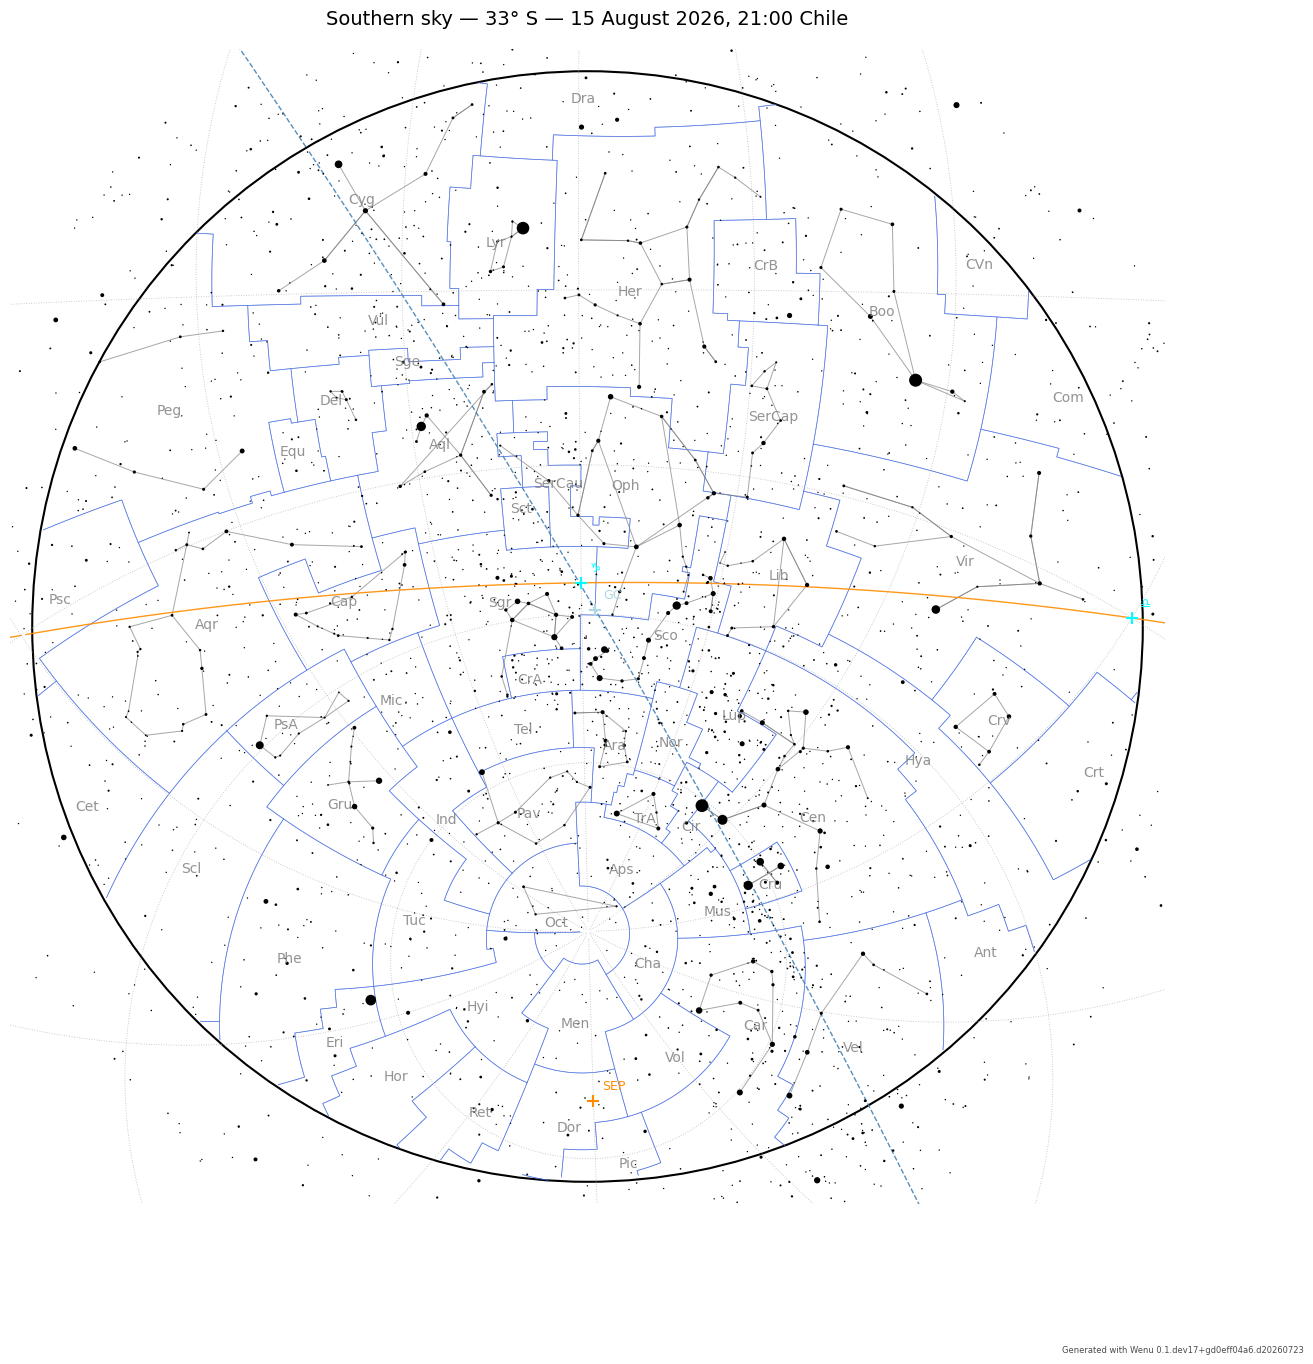

In [17]:
ax.set_title("Southern sky — 33° S — 15 August 2026, 21:00 Chile",fontsize=14,pad=18)
print("Axes lines:",len(ax.lines))
print("Axes patches:",len(ax.patches))
print("Axes collections:",len(ax.collections))
print("Axes texts:",len(ax.texts))

fig.text(
    0.99,
    0.01,
    f"Generated with Wenu {wenu.__version__}",
    ha="right",
    va="bottom",
    fontsize=6,
    alpha=0.7,
)
display(fig)


In [18]:
OUTPUT_FILE=Path("carta_33S_2026-08-15_21h_explicit_wenu.png")
fig.savefig(OUTPUT_FILE,transparent=True,dpi=600,bbox_inches="tight",pad_inches=0.05)
print(OUTPUT_FILE)
print("Saved:",OUTPUT_FILE.resolve())


carta_33S_2026-08-15_21h_explicit_wenu.png
Saved: /Users/fselman/odrive/Dropbox/outreach/laligua/museo/Astronomia101_2026/wenu_laligua/en/carta_33S_2026-08-15_21h_explicit_wenu.png


In [19]:
print(inspect.getsource(type(stars)))

class Stars:
    """
    Hipparcos star field.

    The full magnitude-limited catalogue is stored in ``catalog``.
    The currently selected stars are stored in ``hip_df``.
    """

    def __init__(
        self,
        observer,
        catalog="hipparcos",
        magnitude_limit=5.5,
    ):
        self.observer = observer
        self.catalog_name = catalog
        self.magnitude_limit = magnitude_limit

        # Magnitude-limited catalogue; never modified by altitude filtering.
        self.catalog = None

        # Current altitude-filtered catalogue.
        self.hip_df = None

        # Skyfield Star object corresponding to self.catalog.
        self.skyfield_stars = None

        # Current calculated/projected coordinates.
        self.alt = None
        self.az = None
        self.x = None
        self.y = None
        self.sizes = None

        self.projection = None
        self.artist = None

    def load(self, 
             *,
             catalog=None,
             f

In [20]:
stars.hip_df["magnitude"].describe()


count    2909.000000
mean        5.111805
std         0.873196
min        -0.620000
25%         4.780000
50%         5.380000
75%         5.740000
max         6.000000
Name: magnitude, dtype: float64